In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
%matplotlib inline

In [2]:
iris_df = pd.read_csv('https://github.com/GPShiva/Sparks-Internship/blob/main/Iris.csv?raw=true',index_col = 'Id')
iris_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
iris_df.Species.value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: Species, dtype: int64

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn

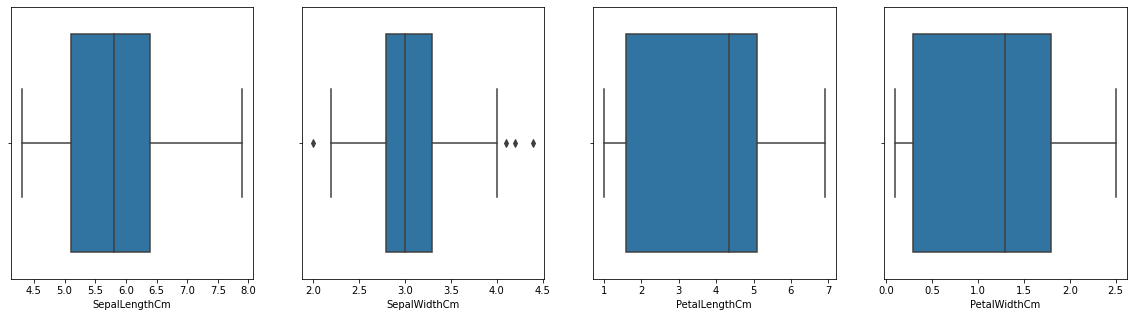

In [5]:
plt.figure(figsize=(20,5))
j = 1
for i in iris_df.iloc[:,:-1].columns:
    plt.subplot(1,4,j)
    sns.boxplot(iris_df[i])
    j+=1

In [6]:
X = iris_df.drop('Species',axis=1)
y = iris_df.Species
X.shape, y.shape

((150, 4), (150,))

In [7]:
from sklearn.model_selection import train_test_split  
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.25, random_state=100)

In [8]:
from sklearn.preprocessing import StandardScaler    
scaler= StandardScaler()  
X_train= scaler.fit_transform(X_train)    
X_test= scaler.transform(X_test)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


[Text(0.4, 0.9, 'X[2] <= -0.762\ngini = 0.666\nsamples = 112\nvalue = [36, 40, 36]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 36\nvalue = [36, 0, 0]'),
 Text(0.5, 0.7, 'X[3] <= 0.59\ngini = 0.499\nsamples = 76\nvalue = [0, 40, 36]'),
 Text(0.2, 0.5, 'X[2] <= 0.713\ngini = 0.133\nsamples = 42\nvalue = [0, 39, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 38\nvalue = [0, 38, 0]'),
 Text(0.3, 0.3, 'X[0] <= 0.299\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.5, 'X[2] <= 0.627\ngini = 0.057\nsamples = 34\nvalue = [0, 1, 33]'),
 Text(0.7, 0.3, 'X[1] <= 0.118\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 0, 30]')]

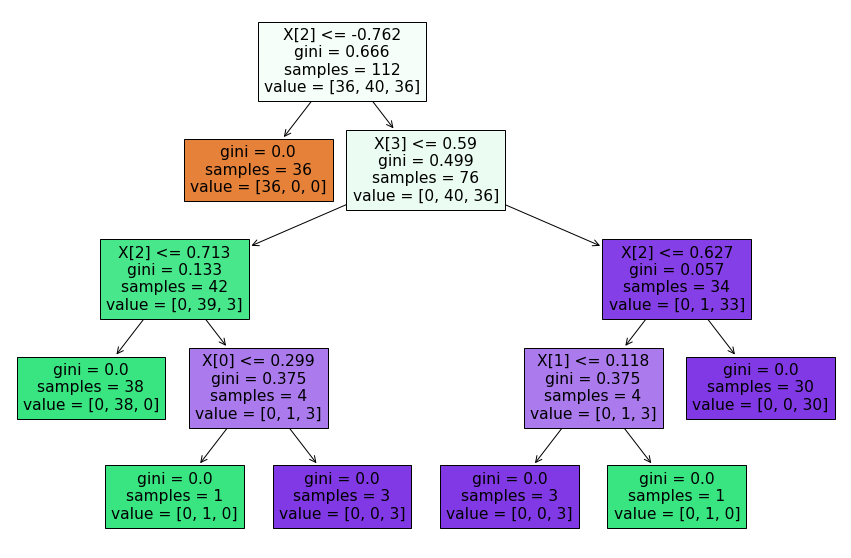

In [10]:
classifier = DecisionTreeClassifier()
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)

In [11]:
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

1.0 0.95


In [12]:
classifier.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

**ccp_alphanon-negative float, default=0.0
Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. By default, no pruning is performed. See Minimal Cost-Complexity Pruning for details.**

0.9910714285714286 0.95


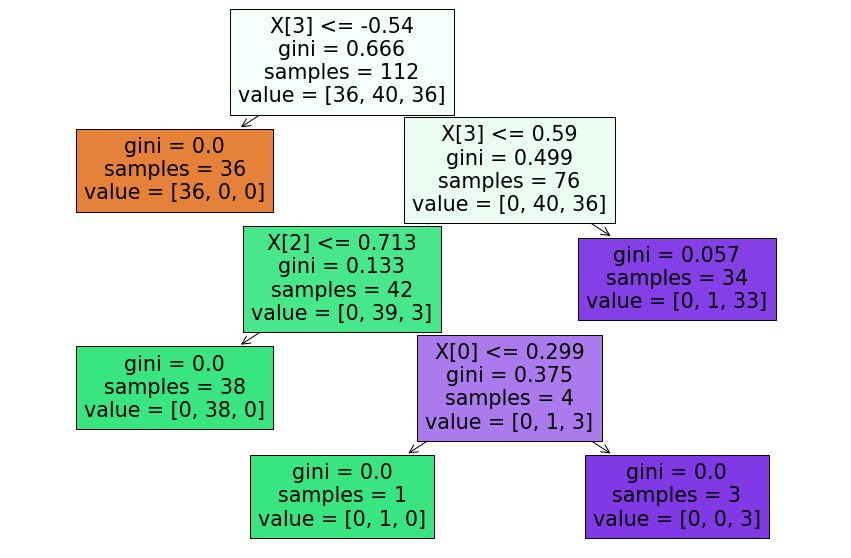

In [13]:
classifier = DecisionTreeClassifier(ccp_alpha=0.01)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**criterion{“gini”, “entropy”, “log_loss”}, default=”gini”
The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain**

1.0 0.95


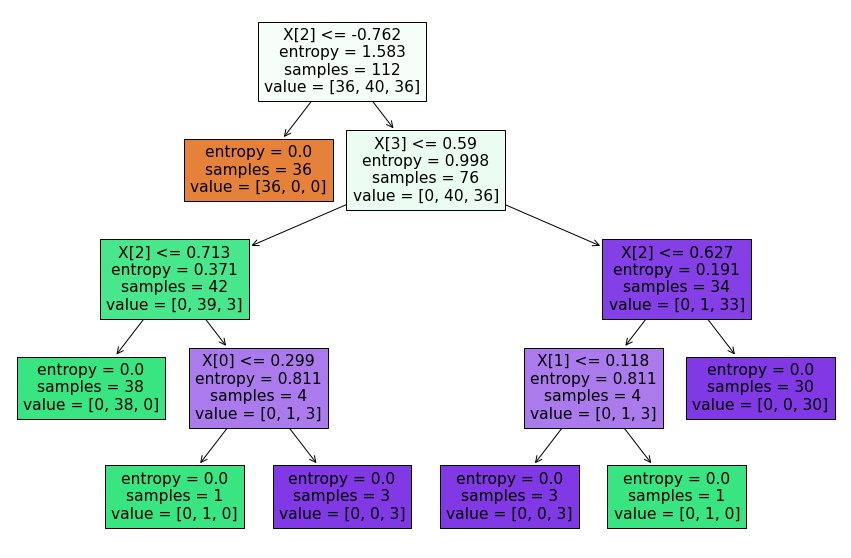

In [14]:
classifier = DecisionTreeClassifier(criterion='entropy')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**splitter{“best”, “random”}, default=”best”
The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.**

1.0 0.95


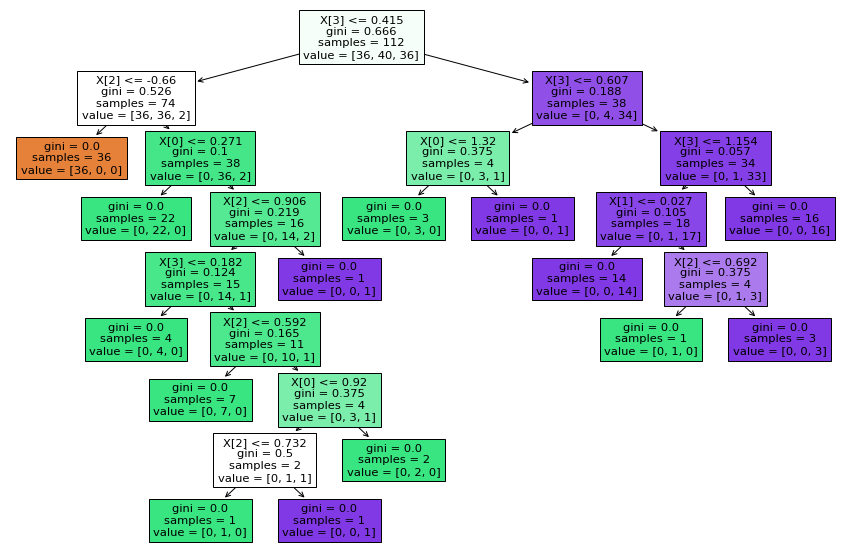

In [15]:
classifier = DecisionTreeClassifier(splitter='random')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

1.0 0.95


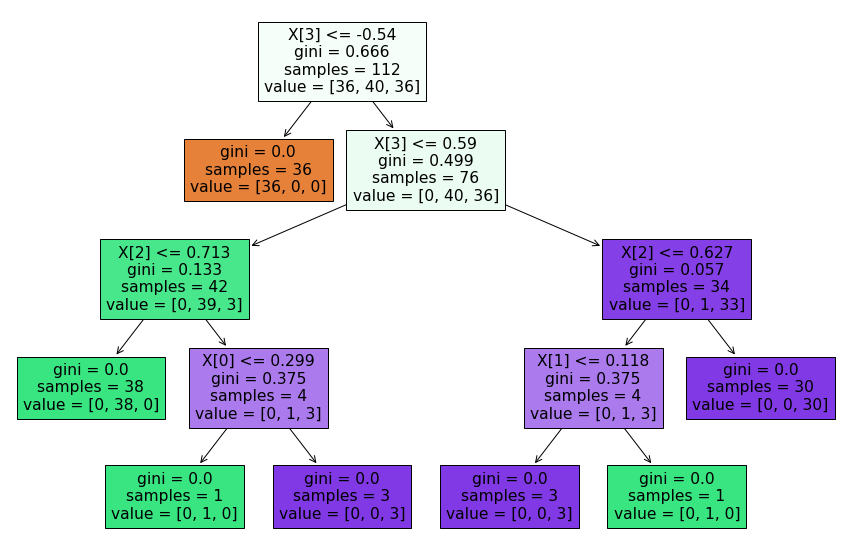

In [16]:
classifier = DecisionTreeClassifier(splitter='best')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**max_depthint, default=None
The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.**

0.9821428571428571 0.95


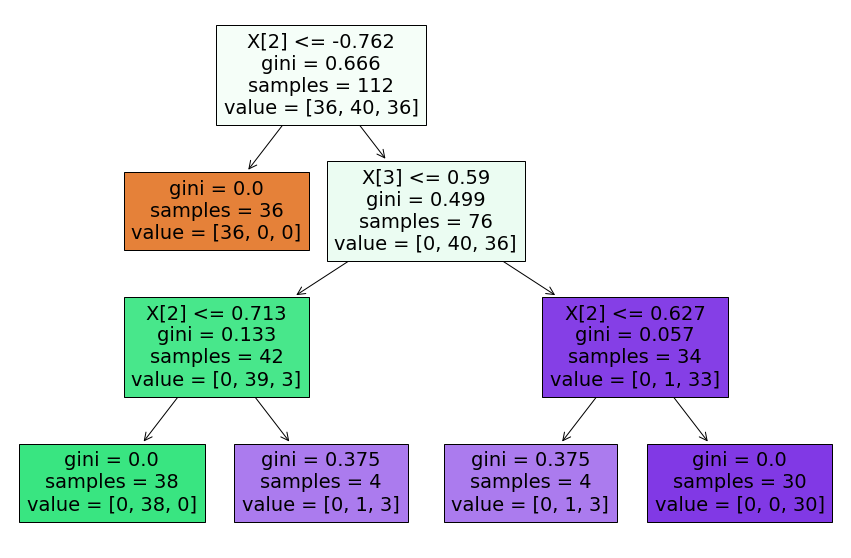

In [17]:
classifier = DecisionTreeClassifier(max_depth=3)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**min_samples_splitint or float, default=2
The minimum number of samples required to split an internal node:
If int, then consider min_samples_split as the minimum number.
If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.**

1.0 0.95


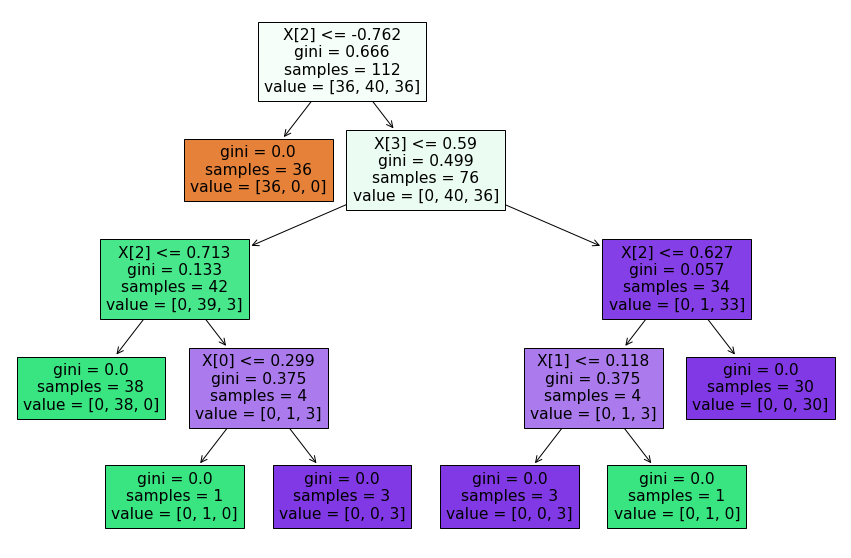

In [18]:
classifier = DecisionTreeClassifier(min_samples_leaf=1)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**min_samples_leafint or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.
If int, then consider min_samples_leaf as the minimum number.
If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.**

1.0 0.95


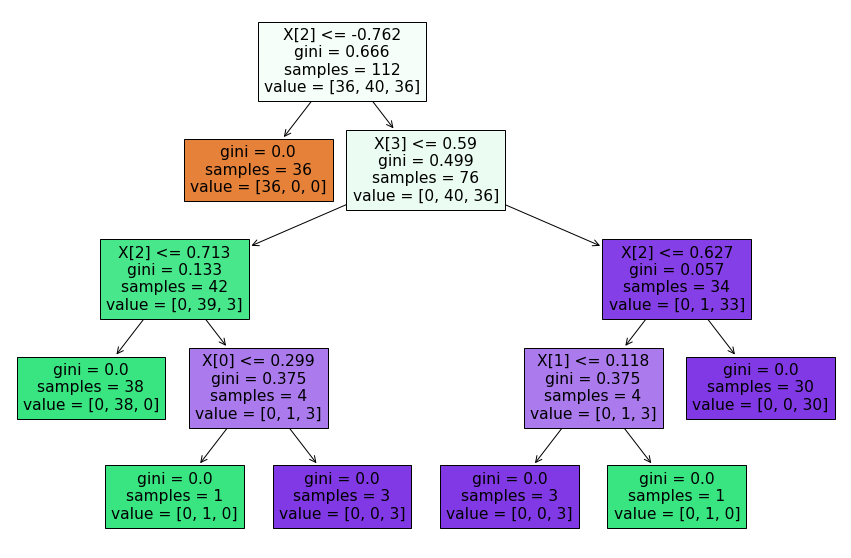

In [19]:
classifier = DecisionTreeClassifier(min_samples_leaf=1)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**min_weight_fraction_leaffloat, default=0.0
The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. Samples have equal weight when sample_weight is not provided.**

1.0 0.95


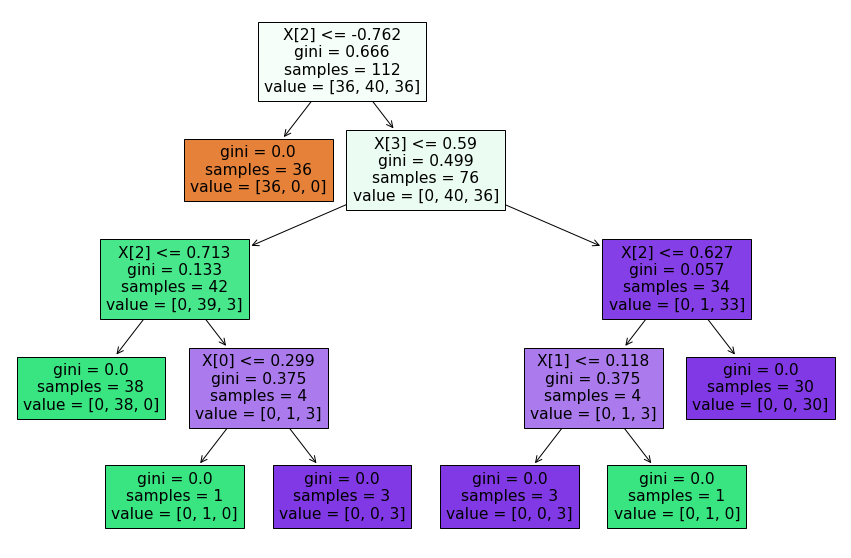

In [20]:
classifier = DecisionTreeClassifier(min_weight_fraction_leaf=0)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**max_featuresint, float or {“auto”, “sqrt”, “log2”}, default=None
The number of features to consider when looking for the best split:**

**If int, then consider max_features features at each split.**

**If float, then max_features is a fraction and int(max_features * n_features) features are considered at each split.**

**If “auto”, then max_features=sqrt(n_features).**

**If “sqrt”, then max_features=sqrt(n_features).**

**If “log2”, then max_features=log2(n_features).**

**If None, then max_features=n_features.**

1.0 0.95


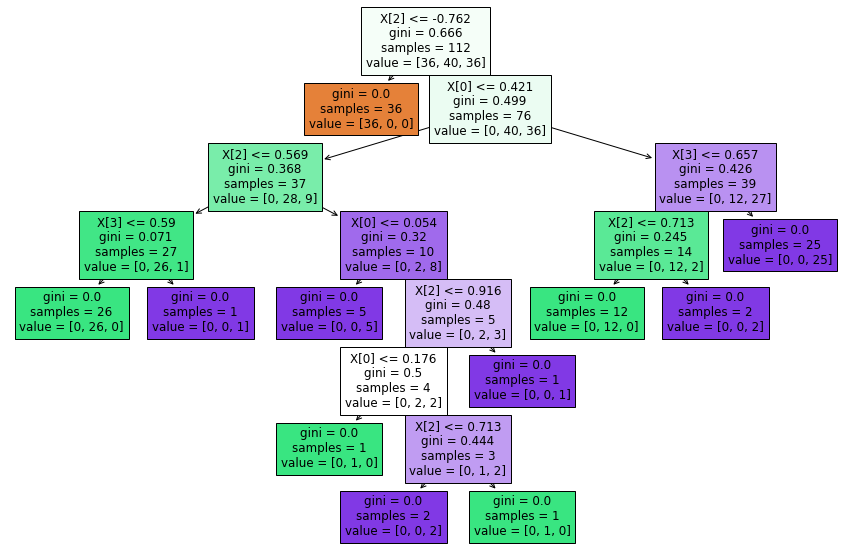

In [21]:
classifier = DecisionTreeClassifier(max_features='auto')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

1.0 0.95


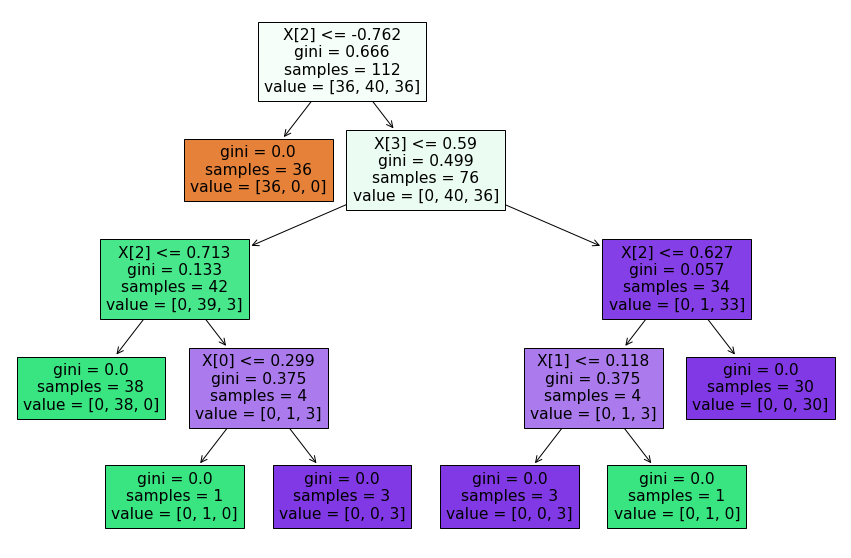

In [22]:
classifier = DecisionTreeClassifier(max_features='sqrt')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

1.0 0.95


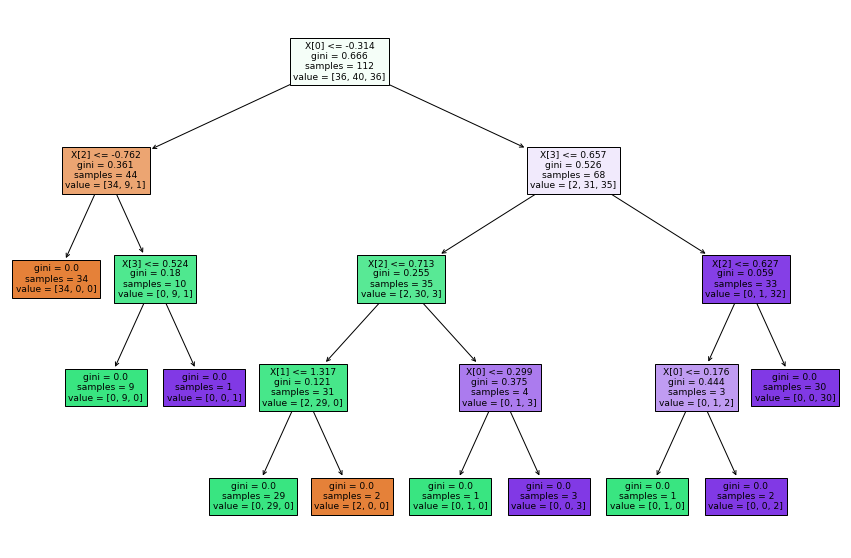

In [23]:
classifier = DecisionTreeClassifier(max_features='log2')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**max_leaf_nodes int, default=None
Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.**

1.0 0.95


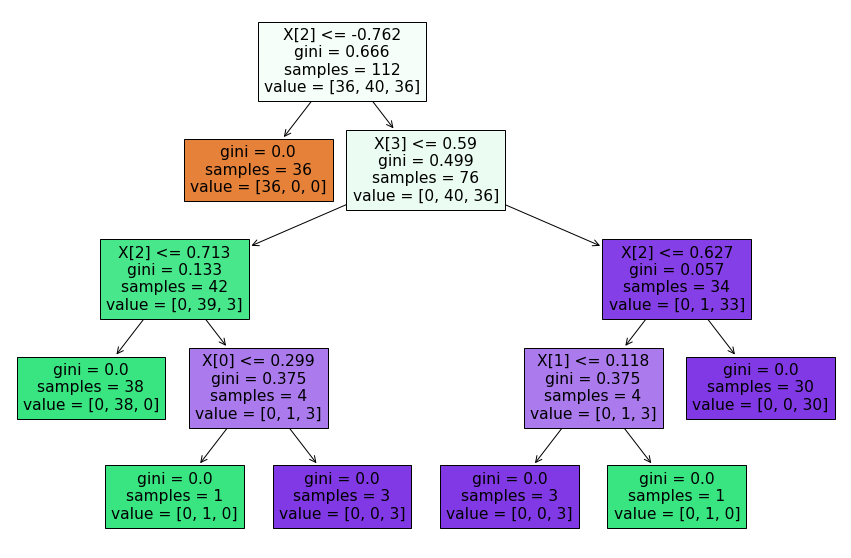

In [24]:
classifier = DecisionTreeClassifier(max_leaf_nodes=10)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**min_impurity_decrease float, default=0.0
A node will be split if this split induces a decrease of the impurity greater than or equal to this value.**

1.0 0.95


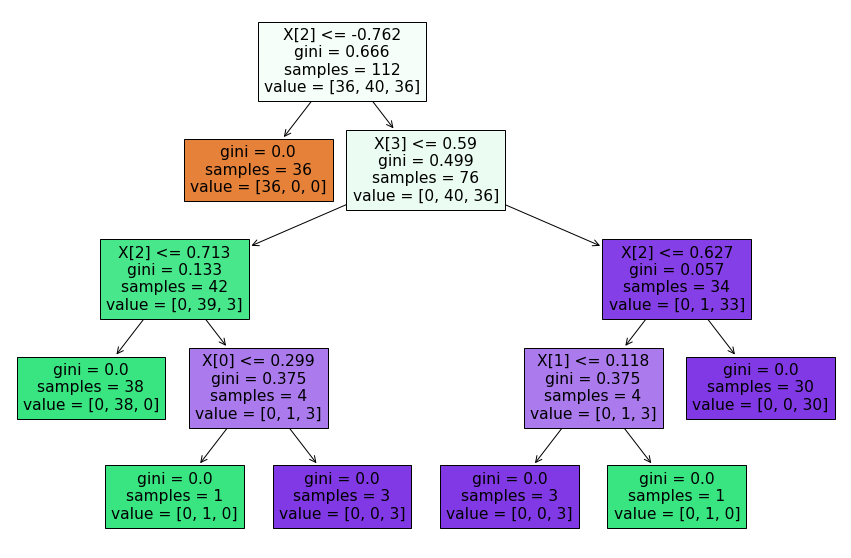

In [25]:
classifier = DecisionTreeClassifier(min_impurity_decrease=0)
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))

**class_weight dict, list of dict or “balanced”, default=None
Weights associated with classes in the form {class_label: weight}. If None, all classes are supposed to have weight one. For multi-output problems, a list of dicts can be provided in the same order as the columns of y.**

1.0 0.95


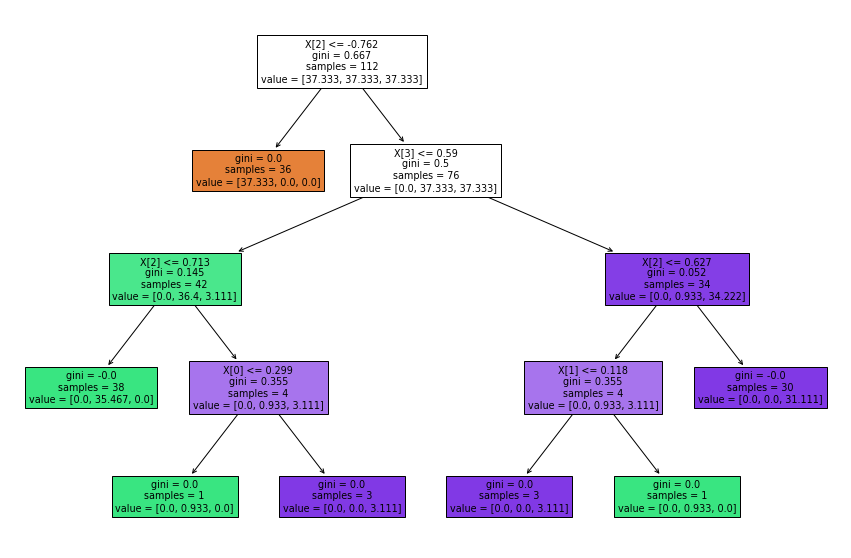

In [26]:
classifier = DecisionTreeClassifier(class_weight='balanced')
classifier.fit(X_train,y_train)
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)
y_train_pred=classifier.predict(X_train)
y_test_pred=classifier.predict(X_test)
print(accuracy_score(y_train,y_train_pred),round(accuracy_score(y_test,y_test_pred),2))